<a href="https://colab.research.google.com/github/airnandabintang-sudo/bintang-ML_Credit_Default_UTS/blob/main/UTS_ML_Credit_Default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Experiment Challenge: Credit Default Prediction
## Muhammad Bintang Airnanda Assalam_2404220003
**Dataset:** Default of Credit Card Clients (Kaggle / UCI), 30.000 observasi
**Target:** `default.payment.next.month` (0 = tidak default, 1 = default)
**Metrik utama:** F1-score | **Metrik pendukung:** Accuracy, Precision, Recall
**Evaluasi:** 5-fold Stratified Cross Validation pada training set + evaluasi pada test set



## Setup: import library dan membaca dataset

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

RANDOM_STATE = 42
TARGET = 'default.payment.next.month'

from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print('File dibaca:', file_name)

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv
File dibaca: UCI_Credit_Card.csv


---
# Experiment 0: Data Understanding & Preparation
## 0.1 Dimensi, struktur, dan tipe data

In [6]:
print('Dimensi dataset (baris, kolom):', df.shape)
print()
df.info()
print()
df.head()

Dimensi dataset (baris, kolom): (30000, 25)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null 

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,"20,000.0000",2,2,1,24,2,2,-1,-1,-2,-2,"3,913.0000","3,102.0000",689.0000,0.0000,0.0000,0.0000,0.0000,689.0000,0.0000,0.0000,0.0000,0.0000,1
1,2,"120,000.0000",2,2,2,26,-1,2,0,0,0,2,"2,682.0000","1,725.0000","2,682.0000","3,272.0000","3,455.0000","3,261.0000",0.0000,"1,000.0000","1,000.0000","1,000.0000",0.0000,"2,000.0000",1
2,3,"90,000.0000",2,2,2,34,0,0,0,0,0,0,"29,239.0000","14,027.0000","13,559.0000","14,331.0000","14,948.0000","15,549.0000","1,518.0000","1,500.0000","1,000.0000","1,000.0000","1,000.0000","5,000.0000",0
3,4,"50,000.0000",2,2,1,37,0,0,0,0,0,0,"46,990.0000","48,233.0000","49,291.0000","28,314.0000","28,959.0000","29,547.0000","2,000.0000","2,019.0000","1,200.0000","1,100.0000","1,069.0000","1,000.0000",0
4,5,"50,000.0000",1,2,1,57,-1,0,-1,0,0,0,"8,617.0000","5,670.0000","35,835.0000","20,940.0000","19,146.0000","19,131.0000","2,000.0000","36,681.0000","10,000.0000","9,000.0000",689.0000,679.0000,0


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,"30,000.0000","15,000.5000","8,660.3984",1.0000,"7,500.7500","15,000.5000","22,500.2500","30,000.0000"
LIMIT_BAL,"30,000.0000","167,484.3227","129,747.6616","10,000.0000","50,000.0000","140,000.0000","240,000.0000","1,000,000.0000"
SEX,"30,000.0000",1.6037,0.4891,1.0000,1.0000,2.0000,2.0000,2.0000
EDUCATION,"30,000.0000",1.8531,0.7903,0.0000,1.0000,2.0000,2.0000,6.0000
MARRIAGE,"30,000.0000",1.5519,0.5220,0.0000,1.0000,2.0000,2.0000,3.0000
AGE,"30,000.0000",35.4855,9.2179,21.0000,28.0000,34.0000,41.0000,79.0000
PAY_0,"30,000.0000",-0.0167,1.1238,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_2,"30,000.0000",-0.1338,1.1972,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_3,"30,000.0000",-0.1662,1.1969,-2.0000,-1.0000,0.0000,0.0000,8.0000
PAY_4,"30,000.0000",-0.2207,1.1691,-2.0000,-1.0000,0.0000,0.0000,8.0000


## 0.2 Variabel target, missing value, dan duplikat

In [8]:
print('Variabel target:', TARGET)
print('Target ada di dataset:', TARGET in df.columns)
print()

print('Missing value per kolom:')
print(df.isnull().sum())
print('Total missing value:', df.isnull().sum().sum())
print()

dup_all = df.duplicated().sum()
dup_wo_id = df.drop(columns=['ID']).duplicated().sum()
print('Duplikat (semua kolom termasuk ID):', dup_all)
print('Duplikat (tanpa kolom ID)         :', dup_wo_id)
print('ID unik:', df['ID'].is_unique)

Variabel target: default.payment.next.month
Target ada di dataset: True

Missing value per kolom:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default.payment.next.month    0
dtype: int64
Total missing value: 0

Duplikat (semua kolom termasuk ID): 0
Duplikat (tanpa kolom ID)  

## 0.3 Nilai yang tidak sesuai atau tidak wajar

In [9]:
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    print(f'--- {col} ---')
    print(df[col].value_counts().sort_index())
    print()

pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
print('--- Status pembayaran (PAY_*) ---')
print(pd.DataFrame({c: df[c].value_counts().sort_index() for c in pay_cols}).fillna(0).astype(int))

--- SEX ---
SEX
1    11888
2    18112
Name: count, dtype: int64

--- EDUCATION ---
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

--- MARRIAGE ---
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

--- Status pembayaran (PAY_*) ---
    PAY_0  PAY_2  PAY_3  PAY_4  PAY_5  PAY_6
-2   2759   3782   4085   4348   4546   4895
-1   5686   6050   5938   5687   5539   5740
 0  14737  15730  15764  16455  16947  16286
 1   3688     28      4      2      0      0
 2   2667   3927   3819   3159   2626   2766
 3    322    326    240    180    178    184
 4     76     99     76     69     84     49
 5     26     25     21     35     17     13
 6     11     12     23      5      4     19
 7      9     20     27     58     58     46
 8     19      1      3      2      1      2


In [10]:
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]

print('Jumlah tagihan negatif per kolom:')
print((df[bill_cols] < 0).sum())
print()
print('Jumlah pembayaran negatif per kolom:')
print((df[amt_cols] < 0).sum())
print()
print('Rentang AGE      :', df['AGE'].min(), 'sampai', df['AGE'].max())
print('Rentang LIMIT_BAL:', df['LIMIT_BAL'].min(), 'sampai', df['LIMIT_BAL'].max())

Jumlah tagihan negatif per kolom:
BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688
dtype: int64

Jumlah pembayaran negatif per kolom:
PAY_AMT1    0
PAY_AMT2    0
PAY_AMT3    0
PAY_AMT4    0
PAY_AMT5    0
PAY_AMT6    0
dtype: int64

Rentang AGE      : 21 sampai 79
Rentang LIMIT_BAL: 10000.0 sampai 1000000.0


## 0.4 Distribusi variabel target

                            jumlah  proporsi
default.payment.next.month                  
0                            23364    0.7788
1                             6636    0.2212


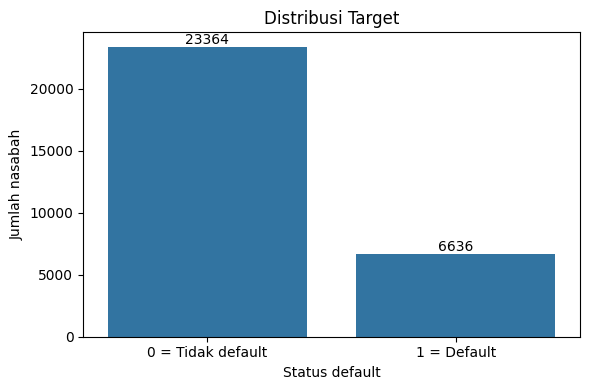

In [32]:
counts = df[TARGET].value_counts().sort_index()
props = df[TARGET].value_counts(normalize=True).sort_index()
print(pd.DataFrame({'jumlah': counts, 'proporsi': props}))

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=TARGET, data=df)
plt.title('Distribusi Target')
plt.xlabel('Status default')
plt.ylabel('Jumlah nasabah')
ax.set_xticklabels(['0 = Tidak default', '1 = Default'])
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 0.5 Keputusan data cleaning (sebelum split)

Dua perapian kategori dilakukan secara deterministik (aturan tetap, tidak belajar dari data), jadi tidak menimbulkan data leakage:

- `EDUCATION` bernilai 0, 5, 6 tidak ada di dokumentasi resmi, digabung ke kategori 4 (others).
- `MARRIAGE` bernilai 0 tidak ada di dokumentasi resmi, digabung ke kategori 3 (others).
- Duplikat: terdapat 35 baris duplikat (tanpa kolom ID), atau sekitar 0,12% dari data. Baris ini tidak dibuang karena jumlahnya sangat kecil dan kemungkinan merupakan nasabah berbeda dengan profil yang mirip, bukan kesalahan input.

Nilai `PAY_*` = -2 dan 0 serta tagihan negatif **tidak** diubah karena punya arti nyata (tidak ada pemakaian, kredit berputar, kelebihan bayar).



In [12]:
DROP_DUPLICATES = False   # ubah ke True jika diputuskan membuang baris duplikat

def clean_categories(data):
    data = data.copy()
    data['EDUCATION'] = data['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
    data['MARRIAGE'] = data['MARRIAGE'].replace({0: 3})
    return data

feature_cols_all = [c for c in df.columns if c != 'ID']
df_model = df.drop_duplicates(subset=feature_cols_all).copy() if DROP_DUPLICATES else df.copy()
df_model = clean_categories(df_model)

print('Jumlah baris yang dipakai:', len(df_model))
print('EDUCATION setelah dirapikan:', sorted(df_model['EDUCATION'].unique()))
print('MARRIAGE setelah dirapikan :', sorted(df_model['MARRIAGE'].unique()))

Jumlah baris yang dipakai: 30000
EDUCATION setelah dirapikan: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE setelah dirapikan : [np.int64(1), np.int64(2), np.int64(3)]


## 0.6 Predictor, target, dan train-test split

- Mengeluarkan `ID` dari predictor.
- Melakukan Split sebelum scaling/encoding apa pun, dengan `stratify=y` agar proporsi kelas terjaga.
- Seluruh scaling dan encoding nanti dilakukan di dalam `Pipeline`, sehingga hanya di-fit pada data latih (termasuk di setiap fold CV).

In [31]:
X = df_model.drop(columns=['ID', TARGET])
y = df_model[TARGET]
print('Jumlah predictor:', X.shape[1])
print('Predictor:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print()
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Proporsi default di train:', round(y_train.mean(), 4))
print('Proporsi default di test :', round(y_test.mean(), 4))

Jumlah predictor: 23
Predictor:
   1. LIMIT_BAL
   2. SEX
   3. EDUCATION
   4. MARRIAGE
   5. AGE
   6. PAY_0
   7. PAY_2
   8. PAY_3
   9. PAY_4
  10. PAY_5
  11. PAY_6
  12. BILL_AMT1
  13. BILL_AMT2
  14. BILL_AMT3
  15. BILL_AMT4
  16. BILL_AMT5
  17. BILL_AMT6
  18. PAY_AMT1
  19. PAY_AMT2
  20. PAY_AMT3
  21. PAY_AMT4
  22. PAY_AMT5
  23. PAY_AMT6

X_train: (24000, 23) | X_test: (6000, 23)
Proporsi default di train: 0.2212
Proporsi default di test : 0.2212


## 0.7 Fungsi evaluasi bersama

Semua eksperimen memakai prosedur evaluasi yang sama:
- CV F1: rata-rata F1 dari 5-fold Stratified CV pada training set.
- Test metrics: model di-fit pada seluruh training set, lalu diuji pada test set (Accuracy, Precision, Recall, F1).

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []   # semua hasil eksperimen dikumpulkan di sini

def evaluate(experiment, name, model, fit=True):
    # CV F1 pada training set
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    if fit:
        model.fit(X_train, y_train)
    pred = model.predict(X_test)
    row = {
        'Experiment': experiment,
        'Model': name,
        'CV F1': cv_scores.mean(),
        'CV F1 Std': cv_scores.std(),
        'Test Accuracy': accuracy_score(y_test, pred),
        'Test Precision': precision_score(y_test, pred, zero_division=0),
        'Test Recall': recall_score(y_test, pred),
        'Test F1': f1_score(y_test, pred),
    }
    results.append(row)
    print(f'[{experiment}] {name}')
    print(pd.Series(row).drop(['Experiment', 'Model']).to_string())
    print('Confusion matrix (baris = aktual, kolom = prediksi):')
    print(confusion_matrix(y_test, pred))
    return model, row

def get_result(experiment, name):
    for r in results:
        if r['Experiment'] == experiment and r['Model'] == name:
            return r

---
# Experiment 1: Baseline Model

Logistic Regression pada data apa adanya (setelah cleaning kategori di 0.5), tanpa scaling dan tanpa encoding. Hasilnya menjadi pembanding untuk eksperimen berikutnya.

In [15]:
baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
baseline, r1 = evaluate('1', 'Baseline Logistic Regression', baseline)

[1] Baseline Logistic Regression
CV F1            0.3367
CV F1 Std        0.0493
Test Accuracy    0.8082
Test Precision   0.6648
Test Recall      0.2675
Test F1          0.3815
Confusion matrix (baris = aktual, kolom = prediksi):
[[4494  179]
 [ 972  355]]


---
# Experiment 2: Preprocessing

Preprocessing yang diterapkan lewat `ColumnTransformer` di dalam `Pipeline`:
- **One-hot encoding** untuk `SEX`, `EDUCATION`, `MARRIAGE` (kategori nominal, bukan urutan).
- **StandardScaler** untuk fitur numerik (`LIMIT_BAL`, `AGE`, `PAY_*`, `BILL_AMT*`, `PAY_AMT*`) karena skalanya sangat berbeda dan Logistic Regression sensitif terhadap skala.

Karena berada di dalam pipeline, scaler dan encoder hanya belajar dari data latih pada setiap fold, sehingga tidak ada data leakage.

In [16]:
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
num_cols = [c for c in X_train.columns if c not in cat_cols]

def make_preprocessor():
    return ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols),
    ])

lr_prep = Pipeline([
    ('prep', make_preprocessor()),
    ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])
lr_prep, r2 = evaluate('2', 'Logistic Regression + Preprocessing', lr_prep)

[2] Logistic Regression + Preprocessing
CV F1            0.3653
CV F1 Std        0.0142
Test Accuracy    0.8088
Test Precision   0.6923
Test Recall      0.2442
Test F1          0.3610
Confusion matrix (baris = aktual, kolom = prediksi):
[[4529  144]
 [1003  324]]


In [17]:
cols = ['CV F1', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']
cmp2 = pd.DataFrame({'Baseline (Exp 1)': [r1[c] for c in cols],
                     'Preprocessing (Exp 2)': [r2[c] for c in cols]}, index=cols)
cmp2['Selisih'] = cmp2['Preprocessing (Exp 2)'] - cmp2['Baseline (Exp 1)']
cmp2

,Baseline (Exp 1),Preprocessing (Exp 2),Selisih
CV F1,0.3367,0.3653,0.0287
Test Accuracy,0.8082,0.8088,0.0007
Test Precision,0.6648,0.6923,0.0275
Test Recall,0.2675,0.2442,-0.0234
Test F1,0.3815,0.3610,-0.0205


**Interpretasi Experiment 2** Preprocessing memberi hasil yang tidak konsisten. CV F1 naik dari 0,3367 ke 0,3653 dan model jauh lebih stabil (std CV turun dari 0,0493 ke 0,0142), tetapi Test F1 turun dari 0,3815 ke 0,3610 karena recall turun (0,2675 ke 0,2442). Jadi preprocessing tidak memberi peningkatan yang jelas pada F1, namun tetap dipertahankan karena membuat model lebih stabil.

---
# Experiment 3: Model Comparison

Tiga model dievaluasi dengan prosedur yang sama (preprocessing yang sama dari Experiment 2, 5-fold CV, lalu test set):
1. Logistic Regression
2. Decision Tree
3. Random Forest

Model terbaik dipilih **berdasarkan CV F1** (bukan test set, agar test set tetap menjadi data uji yang murni).

In [18]:
models3 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

fitted3 = {}
for name, mdl in models3.items():
    pipe = Pipeline([('prep', make_preprocessor()), ('model', mdl)])
    fitted3[name], _ = evaluate('3', name, pipe)
    print('-' * 60)

[3] Logistic Regression
CV F1            0.3653
CV F1 Std        0.0142
Test Accuracy    0.8088
Test Precision   0.6923
Test Recall      0.2442
Test F1          0.3610
Confusion matrix (baris = aktual, kolom = prediksi):
[[4529  144]
 [1003  324]]
------------------------------------------------------------
[3] Decision Tree
CV F1            0.3944
CV F1 Std        0.0110
Test Accuracy    0.7195
Test Precision   0.3736
Test Recall      0.3964
Test F1          0.3846
Confusion matrix (baris = aktual, kolom = prediksi):
[[3791  882]
 [ 801  526]]
------------------------------------------------------------
[3] Random Forest
CV F1            0.4730
CV F1 Std        0.0077
Test Accuracy    0.8138
Test Precision   0.6378
Test Recall      0.3662
Test F1          0.4653
Confusion matrix (baris = aktual, kolom = prediksi):
[[4397  276]
 [ 841  486]]
------------------------------------------------------------


In [19]:
comp3 = pd.DataFrame([r for r in results if r['Experiment'] == '3']).set_index('Model')
comp3 = comp3[['CV F1', 'CV F1 Std', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']]
display(comp3)

best_name = comp3['CV F1'].idxmax()
print('Model terbaik berdasarkan CV F1:', best_name)

,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1
Model,,,,,,
Logistic Regression,0.3653,0.0142,0.8088,0.6923,0.2442,0.3610
Decision Tree,0.3944,0.0110,0.7195,0.3736,0.3964,0.3846
Random Forest,0.4730,0.0077,0.8138,0.6378,0.3662,0.4653


Model terbaik berdasarkan CV F1: Random Forest


**Interpretasi Experiment 3** *Random Forest adalah model terbaik: CV F1 0,4730 dan Test F1 0,4653, di atas Decision Tree (0,3944 / 0,3846) dan Logistic Regression (0,3653 / 0,3610). Logistic Regression punya precision tertinggi tetapi recall terendah, sedangkan Decision Tree cenderung overfitting. Random Forest memberi keseimbangan precision dan recall terbaik, sehingga dipakai pada Experiment 4.

---
# Experiment 4: Hyperparameter Tuning

`GridSearchCV` dengan 5-fold Stratified CV, `scoring='f1'`, pada model terbaik dari Experiment 3. Grid disesuaikan otomatis dengan model terpilih.

> Catatan waktu: tuning Random Forest bisa memakan beberapa menit sampai belasan menit di Colab.

In [20]:
param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10],
        'model__class_weight': [None, 'balanced'],
        'model__solver': ['lbfgs', 'liblinear'],
    },
    'Decision Tree': {
        'model__max_depth': [3, 5, 7, 10, None],
        'model__min_samples_leaf': [1, 10, 50],
        'model__criterion': ['gini', 'entropy'],
        'model__class_weight': [None, 'balanced'],
    },
    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [6, 10, None],
        'model__min_samples_leaf': [1, 5],
        'model__class_weight': [None, 'balanced'],
    },
}
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
}

print('Model yang dituning:', best_name)
print('Hyperparameter yang diuji:')
for k, v in param_grids[best_name].items():
    print(' ', k, '->', v)
n_combo = int(np.prod([len(v) for v in param_grids[best_name].values()]))
print('Jumlah kombinasi:', n_combo, '| total fit (x5 fold):', n_combo * 5)

Model yang dituning: Random Forest
Hyperparameter yang diuji:
  model__n_estimators -> [100, 200]
  model__max_depth -> [6, 10, None]
  model__min_samples_leaf -> [1, 5]
  model__class_weight -> [None, 'balanced']
Jumlah kombinasi: 24 | total fit (x5 fold): 120


In [21]:
pipe4 = Pipeline([('prep', make_preprocessor()), ('model', base_models[best_name])])
grid = GridSearchCV(
    pipe4, param_grid=param_grids[best_name], scoring='f1',
    cv=cv, n_jobs=-1 if best_name != 'Random Forest' else 1, refit=True, verbose=1,
)
grid.fit(X_train, y_train)

print('Kombinasi hyperparameter terbaik:', grid.best_params_)
print('Best CV F1-score:', round(grid.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Kombinasi hyperparameter terbaik: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Best CV F1-score: 0.545


In [22]:
# Evaluasi model hasil tuning pada test set.
# CV F1 yang dilaporkan = best CV F1 dari GridSearchCV (tidak dihitung ulang).
tuned = grid.best_estimator_
pred4 = tuned.predict(X_test)
r4 = {
    'Experiment': '4', 'Model': f'Tuned {best_name}',
    'CV F1': grid.best_score_,
    'CV F1 Std': grid.cv_results_['std_test_score'][grid.best_index_],
    'Test Accuracy': accuracy_score(y_test, pred4),
    'Test Precision': precision_score(y_test, pred4, zero_division=0),
    'Test Recall': recall_score(y_test, pred4),
    'Test F1': f1_score(y_test, pred4),
}
results.append(r4)
print(pd.Series(r4).drop(['Experiment', 'Model']).to_string())
print('Confusion matrix:')
print(confusion_matrix(y_test, pred4))

CV F1            0.5450
CV F1 Std        0.0027
Test Accuracy    0.7873
Test Precision   0.5172
Test Recall      0.5772
Test F1          0.5456
Confusion matrix:
[[3958  715]
 [ 561  766]]


In [23]:
r3_best = get_result('3', best_name)
cmp4 = pd.DataFrame({'Sebelum tuning (Exp 3)': [r3_best[c] for c in cols],
                     'Setelah tuning (Exp 4)': [r4[c] for c in cols]}, index=cols)
cmp4['Selisih'] = cmp4['Setelah tuning (Exp 4)'] - cmp4['Sebelum tuning (Exp 3)']
cmp4

,Sebelum tuning (Exp 3),Setelah tuning (Exp 4),Selisih
CV F1,0.4730,0.5450,0.0720
Test Accuracy,0.8138,0.7873,-0.0265
Test Precision,0.6378,0.5172,-0.1206
Test Recall,0.3662,0.5772,0.2110
Test F1,0.4653,0.5456,0.0803


In [33]:
print('Kombinasi hyperparameter terbaik:')
for k, v in grid.best_params_.items():
    print(f'  {k.replace("model__", "")} = {v}')

Kombinasi hyperparameter terbaik:
  class_weight = balanced
  max_depth = 10
  min_samples_leaf = 5
  n_estimators = 200


**Interpretasi Experiment 4** *Tuning meningkatkan performa. CV F1 naik dari 0,4730 ke 0,5450 dan Test F1 naik dari 0,4653 ke 0,5456. Peningkatan terutama berasal dari recall (0,3662 ke 0,5772) berkat class_weight='balanced', dengan konsekuensi precision (0,6378 ke 0,5172) dan accuracy (0,8138 ke 0,7873) turun. Penurunan accuracy wajar karena yang dioptimalkan adalah F1.

---
# Experiment 5: Advanced Model

Metode boosting: **XGBoost** (jika tersedia, di Colab sudah terpasang). Jika XGBoost tidak tersedia, otomatis memakai **Gradient Boosting** dari scikit-learn. Prosedur evaluasi sama dengan eksperimen sebelumnya.

In [39]:
from xgboost import XGBClassifier

# Rasio kelas negatif : positif dari training set (sekitar 3,5)
spw = (y_train == 0).sum() / (y_train == 1).sum()
print('scale_pos_weight:', round(spw, 3))

adv_name = 'XGBoost (scale_pos_weight)'
adv_model = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1,
)

print('Model advanced:', adv_name)
adv_pipe = Pipeline([('prep', make_preprocessor()), ('model', adv_model)])
adv_pipe, r5 = evaluate('5', adv_name, adv_pipe)

scale_pos_weight: 3.521
Model advanced: XGBoost (scale_pos_weight)
[5] XGBoost (scale_pos_weight)
CV F1            0.5395
CV F1 Std        0.0086
Test Accuracy    0.7625
Test Precision   0.4718
Test Recall      0.6187
Test F1          0.5354
Confusion matrix (baris = aktual, kolom = prediksi):
[[3754  919]
 [ 506  821]]


**Interpretasi Experiment 5** XGBoost dengan scale_pos_weight (3,521) mencapai CV F1 0,5395 dan Test F1 0,5354, naik jauh dibanding XGBoost tanpa penanganan imbalance (0,4685). Namun hasilnya masih sedikit di bawah Tuned Random Forest (CV F1 0,5450; Test F1 0,5456), dengan selisih sekitar 0,01 yang tergolong kecil. XGBoost unggul di recall (0,6187 vs 0,5772) tetapi lebih rendah di precision (0,4718 vs 0,5172) dan accuracy (0,7625 vs 0,7873). Jadi model advanced tidak memberi peningkatan dibanding Tuned Random Forest, dan penanganan imbalance terbukti menjadi faktor utama peningkatan performa, bukan kompleksitas model.

---
# Ringkasan Hasil Seluruh Eksperimen


In [44]:
# Menghilangkan duplikat dari list 'results' berdasarkan kombinasi 'Experiment' dan 'Model'
seen = set()
unique_results = []
for r in results:
    identifier = (r['Experiment'], r['Model'])
    if r['Model'] != 'XGBoost' and identifier not in seen:
        seen.add(identifier)
        unique_results.append(r)

results = unique_results

# Memperbarui DataFrame summary
summary = pd.DataFrame(results)
summary = summary[['Experiment', 'Model', 'CV F1', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']]
display(summary)

# Simpan kembali file CSV yang baru
summary.round(4).to_csv('ringkasan_hasil_eksperimen.csv', index=False)
print('Tersimpan versi baru tanpa duplikasi: ringkasan_hasil_eksperimen.csv')

,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,1,Baseline Logistic Regression,0.3367,0.8082,0.6648,0.2675,0.3815
1,2,Logistic Regression + Preprocessing,0.3653,0.8088,0.6923,0.2442,0.3610
2,3,Logistic Regression,0.3653,0.8088,0.6923,0.2442,0.3610
3,3,Decision Tree,0.3944,0.7195,0.3736,0.3964,0.3846
4,3,Random Forest,0.4730,0.8138,0.6378,0.3662,0.4653
5,4,Tuned Random Forest,0.5450,0.7873,0.5172,0.5772,0.5456
6,5,XGBoost (scale_pos_weight),0.5395,0.7625,0.4718,0.6187,0.5354


Tersimpan versi baru tanpa duplikasi: ringkasan_hasil_eksperimen.csv


In [36]:
# Model dengan CV F1 tertinggi di seluruh eksperimen
best_overall = summary.loc[[summary['CV F1'].idxmax()]]
print('Model dengan CV F1 tertinggi:')
display(best_overall)

Model dengan CV F1 tertinggi:


,Experiment,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
5,4,Tuned Random Forest,0.5450,0.7873,0.5172,0.5772,0.5456


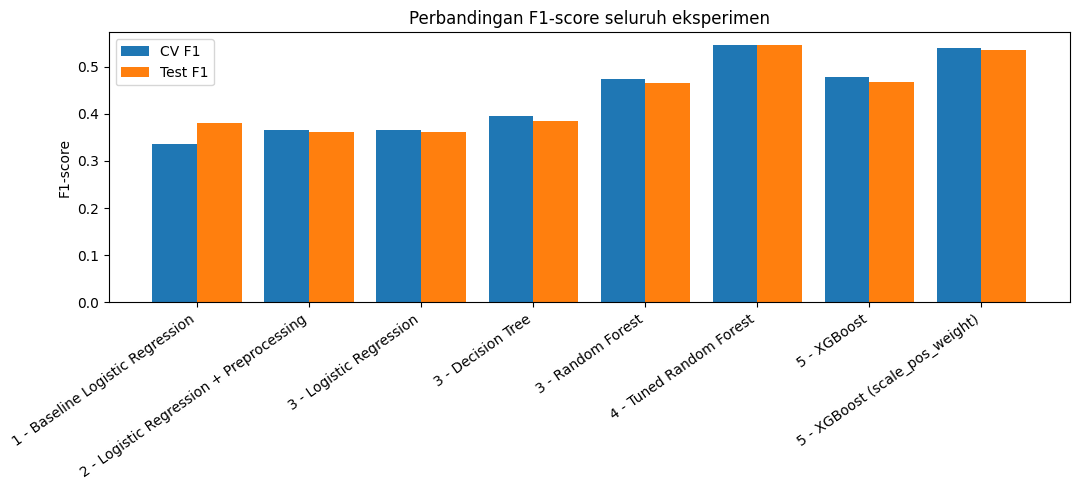

In [37]:
# Grafik perbandingan F1 (CV vs Test)
plot_df = summary.copy()
plot_df['Label'] = plot_df['Experiment'] + ' - ' + plot_df['Model']
x = np.arange(len(plot_df))
plt.figure(figsize=(11, 5))
plt.bar(x - 0.2, plot_df['CV F1'], width=0.4, label='CV F1')
plt.bar(x + 0.2, plot_df['Test F1'], width=0.4, label='Test F1')
plt.xticks(x, plot_df['Label'], rotation=35, ha='right')
plt.ylabel('F1-score')
plt.title('Perbandingan F1-score seluruh eksperimen')
plt.legend()
plt.tight_layout()
plt.show()

---
# Kesimpulan dan Model Final

Tuned Random Forest tetap layak dipilih sebagai model final: F1 tertinggi di CV dan test, lebih sederhana, serta precision dan accuracy lebih baik. Kalau prioritas Anda mendeteksi sebanyak mungkin nasabah default, XGBoost bisa dijadikan alternatif karena recall-nya lebih tinggi. Tapi berdasarkan metrik utama (F1), pilihan jatuh ke Tuned RF.